In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data from notebook 01
df = pd.read_csv('../data/kalman_results.csv', index_col=0, parse_dates=True)

print(f"Loaded {len(df)} minutes of data")
print(f"Date range: {df.index[0]} to {df.index[-1]}")

Loaded 619397 minutes of data
Date range: 2020-01-02 16:28:00+00:00 to 2026-03-20 22:13:00+00:00


In [50]:
# =======================================================
# BUILD strategy_df WITH ALL REQUIRED COLUMNS
# =======================================================
strategy_df = df[['X_close', 'Y_close', 'spread_kalman', 'z_kalman_rolling', 'beta_kalman']].copy()
strategy_df.columns = ['X_close', 'Y_close', 'spread', 'z_score', 'beta']

print(f"strategy_df built: {len(strategy_df)} rows")
print(strategy_df.head())

strategy_df built: 619397 rows
                           X_close   Y_close     spread   z_score      beta
timestamp                                                                  
2020-01-02 16:28:00+00:00  53.7902  125.9100  27.266356 -0.188339  1.833859
2020-01-02 16:29:00+00:00  53.8025  125.9699  27.297870  0.075246  1.833967
2020-01-02 16:30:00+00:00  53.8100  125.9000  27.220863 -0.569544  1.833844
2020-01-02 16:31:00+00:00  53.8200  125.8800  27.193607 -0.789390  1.833638
2020-01-02 16:32:00+00:00  53.8200  125.8500  27.177326 -0.912355  1.833383


In [51]:
# =======================================================
# NO-TRADE ZONE (COST-AWARE)
# =======================================================
threshold = 2.5      
exit_threshold = 0.5 
delta_min = 0.05     # Inertia threshold for beta stability

position = 0
positions = []
last_beta = strategy_df['beta'].iloc[0]

for i in range(len(strategy_df)):
    z = strategy_df['z_score'].iloc[i]
    current_beta = strategy_df['beta'].iloc[i]
    change_dist = abs(current_beta - last_beta)
    
    if position == 0:
        if abs(z) > threshold and change_dist < delta_min:
            position = -1 if z > 0 else 1
            last_beta = current_beta
    else:
        if (position == 1 and z > -exit_threshold) or (position == -1 and z < exit_threshold):
            position = 0
        elif change_dist > (delta_min * 3):
            position = 0

    positions.append(position)

strategy_df['position'] = positions

print("Signals generated (Cost-Aware & No-Trade Zone applied)")
print(f"Long trades:  {(strategy_df['position'] == 1).sum()} minutes")
print(f"Short trades: {(strategy_df['position'] == -1).sum()} minutes")

Signals generated (Cost-Aware & No-Trade Zone applied)
Long trades:  597 minutes
Short trades: 621 minutes


In [52]:
# =======================================================
# PnL CALCULATION (HF Realism)
# =======================================================
strategy_df['ret_X'] = strategy_df['X_close'].pct_change()
strategy_df['ret_Y'] = strategy_df['Y_close'].pct_change()

# Spread return using dynamic beta
strategy_df['spread_return'] = strategy_df['ret_Y'] - strategy_df['beta'] * strategy_df['ret_X']

# Capital factor: how much capital the spread leg uses
strategy_df['capital_factor'] = 1 + np.abs(strategy_df['beta'])
strategy_df['strategy_return'] = (strategy_df['spread_return'] * strategy_df['position'].shift(1)) / strategy_df['capital_factor']

# Transaction costs (per-share model)
transaction_cost = 0.0005 
position_changes = strategy_df['position'].diff().abs() > 0
strategy_df.loc[position_changes, 'strategy_return'] -= transaction_cost

# Additive equity (no compounding for HF)
strategy_df['strategy_equity'] = 1 + strategy_df['strategy_return'].fillna(0).cumsum()
strategy_df['buyhold_equity'] = (1 + strategy_df['ret_Y'].fillna(0)).cumprod()

print("Returns calculated")
print(f"  Strategy final equity: {strategy_df['strategy_equity'].iloc[-1]:.2f}")
print(f"  Buy & Hold final equity: {strategy_df['buyhold_equity'].iloc[-1]:.2f}")

Returns calculated
  Strategy final equity: 1.23
  Buy & Hold final equity: 2.37


In [53]:
# =======================================================
# METRICS (Intraday/Additive)
# =======================================================
def calculate_metrics(returns):
    returns_clean = returns.dropna()
    if len(returns_clean) == 0 or returns_clean.std() == 0:
        return {'sharpe': 0, 'total_return': 0, 'max_drawdown': 0, 'win_rate': 0}

    MINUTES_PER_YEAR = 252 * 390
    sharpe = (returns_clean.mean() / returns_clean.std()) * np.sqrt(MINUTES_PER_YEAR)
    total_ret = returns_clean.sum()

    cum_returns = returns_clean.cumsum()
    running_max = cum_returns.cummax()
    drawdown = cum_returns - running_max
    max_dd = (drawdown / (1 + running_max)).min()

    wins = (returns_clean > 0).sum()
    total_trades = (returns_clean != 0).sum()
    win_rate = wins / total_trades if total_trades > 0 else 0

    return {'sharpe': sharpe, 'total_return': total_ret, 'max_drawdown': max_dd, 'win_rate': win_rate}

metrics_strategy = calculate_metrics(strategy_df['strategy_return'])
metrics_buyhold = calculate_metrics(strategy_df['ret_Y'])

print("\n" + "="*50)
print("PERFORMANCE METRICS (HF ADJUSTED)")
print("="*50)
print(f"{'Metric':<20} {'Strategy':>16} {'Buy & Hold':>12}")
print("-"*50)
print(f"{'Sharpe Ratio':<20} {metrics_strategy['sharpe']:>16.3f} {metrics_buyhold['sharpe']:>12.3f}")
print(f"{'Total Return':<20} {metrics_strategy['total_return']:>15.1%} {metrics_buyhold['total_return']:>11.1%}")
print(f"{'Max Drawdown':<20} {metrics_strategy['max_drawdown']:>15.1%} {metrics_buyhold['max_drawdown']:>11.1%}")
print(f"{'Win Rate':<20} {metrics_strategy['win_rate']:>15.1%} {metrics_buyhold['win_rate']:>11.1%}")
print("="*50)


PERFORMANCE METRICS (HF ADJUSTED)
Metric                       Strategy   Buy & Hold
--------------------------------------------------
Sharpe Ratio                    1.055        0.553
Total Return                   22.8%      130.5%
Max Drawdown                   -3.1%      -61.4%
Win Rate                       45.6%       50.3%


C:\Users\aluno\Documents\quant_project\quant_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


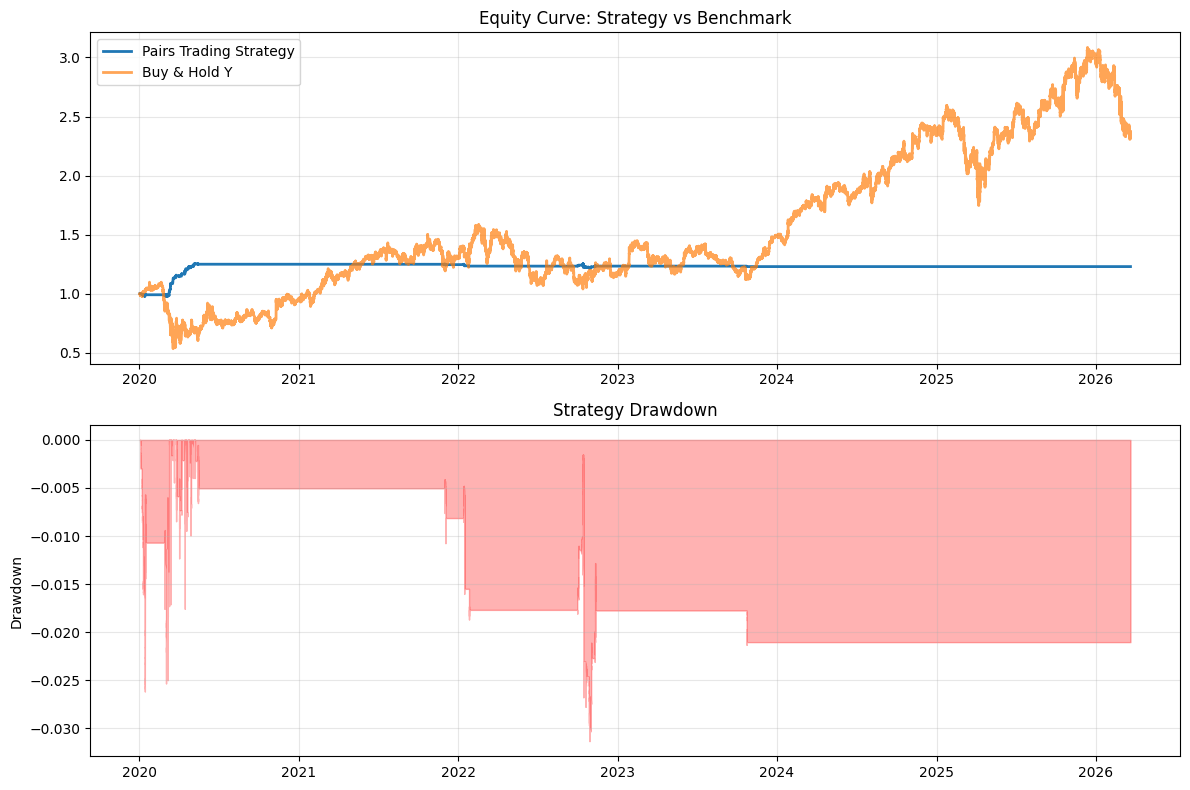

In [54]:
# =======================================================
# PLOTS
# =======================================================
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(strategy_df.index, strategy_df['strategy_equity'], 
             label='Pairs Trading Strategy', linewidth=2)
axes[0].plot(strategy_df.index, strategy_df['buyhold_equity'], 
             label='Buy & Hold Y', linewidth=2, alpha=0.7)
axes[0].set_title('Equity Curve: Strategy vs Benchmark')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

cum_rets = strategy_df['strategy_return'].fillna(0).cumsum()
running_max = cum_rets.cummax()
drawdown = (cum_rets - running_max) / (1 + running_max)

axes[1].fill_between(strategy_df.index, 0, drawdown, color='red', alpha=0.3)
axes[1].set_title('Strategy Drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/02_strategy_performance.png', dpi=150)
plt.show()

In [55]:
# =======================================================
# SAVE
# =======================================================
strategy_df.to_csv('../data/strategy_results.csv')

import json
metrics_dict = {
    'strategy': metrics_strategy,
    'buy_hold': metrics_buyhold,
    'parameters': {'threshold': threshold, 'exit_threshold': exit_threshold, 'delta_min': delta_min}
}

with open('../data/strategy_metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=2)

print("Data saved to data/strategy_results.csv")
print("Metrics saved to data/strategy_metrics.json")
print("\nBASELINE STRATEGY COMPLETE")

Data saved to data/strategy_results.csv
Metrics saved to data/strategy_metrics.json

BASELINE STRATEGY COMPLETE


In [56]:
df = pd.read_csv('../data/strategy_results.csv', index_col=0, parse_dates=True)
print(df.columns.tolist())

['X_close', 'Y_close', 'spread', 'z_score', 'beta', 'position', 'ret_X', 'ret_Y', 'spread_return', 'capital_factor', 'strategy_return', 'strategy_equity', 'buyhold_equity']
